# Temporal Fusion Transformer: Time Series Forecasting with Interpretability

- https://towardsdatascience.com/temporal-fusion-transformer-googles-model-for-interpretable-time-series-forecasting-5aa17beb621

- data, trend, seasonality, volatility, drift and rare events, everything should be considered in order to create a competitive model!

signal processing etc

Requirements)

- time series not only multivariate, but may also be different distributions trained inside a single model.

- Autoregressive methods (e.g. ARIMA, DeepAR) cannot take use historical information that is unkown in the future. causal models.

- static variables independent from time(within the predicting timeframe) should also be considered. (like cities)

- Explainability! through the Multi attention head

- 별도) autogluon으로 파라미터 최적화

3 types of variables: past temporal, future temporal(but determined), static.

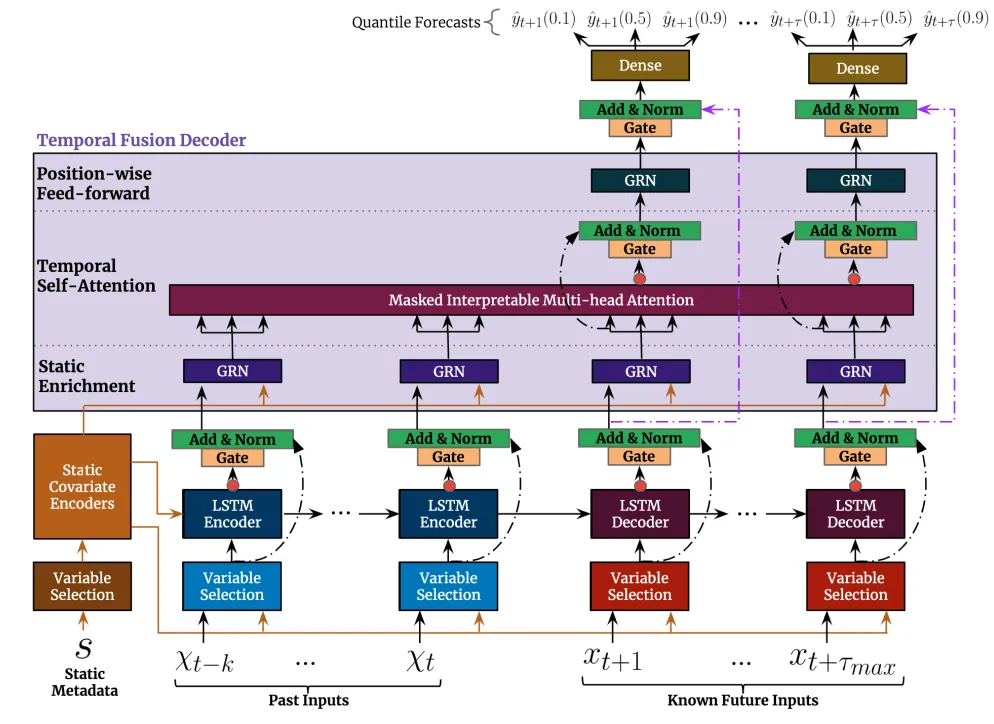

$x_t$: present, $k$: lookback window, $\tau_{max}$: step ahead window

## Gated Residual Networks

- consists of 2 dense layers and 2 activation functions, ELU(Exponential Linear Unit) and GLU (Gated Linear Units).

ELU) Captures non-linear relationship and some useful characteristics like evading gradient disappearing and smooth transition between negative and postive valeus

GLU) Weights the important features.

ELU to capture complex relationships, GLU to filter the prioritize the crucial features.

Residual connection to the Add Layer allows the model to skip the input entirely or utilize static variables!

Add operation: Learn the direct difference(residual) between input and output instead of entire mapping.

Norm operation: literally the mean std normalization but with learnable multiplied weight and added bias.



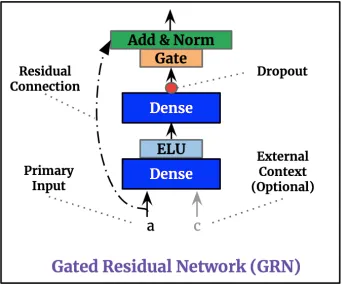

## Variable Selection Network (VSN)

- GRN is under the hood to filter complex noise from meaningful data

- flatten all the past inputs to `Ξ_t` -> soft max -> normalized vector

- output $\tilde\xi_{t}$: linear combination of ξ_t and u

- for equal time $t$, identical GRN is applied

- `c` context vector is the `temporal` context that changes over time. Not applied to static variables.

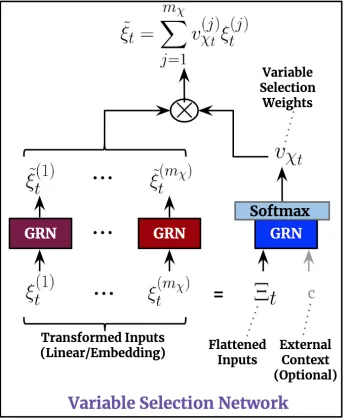

## LSTM Encoder Decoder

- Encoder takes in the past information, which is more optimized for analyzing and distilling past data

- Decoder which is more optimized for creating outputs contributes to the prediction directly

How do we mix the context or the static variable with time varying data? The model cannot temporal difference of fixed data like the static variables. 시간에 따라 반영 정도가 달라져야함

"Initialize the LSTM with it": hidden state and cell state is initialized as `c_h` and `c_c` produced from the static covariate encoder of TFT.
-> context, static variable, exogenous information as the "condition" of φ, context-aware embeddings.


## Interpretable Multi-Head Attention

Traditional MHA consists of Query/Key/Value heads that are uninterpretable.

TFT uses grouped weight sharing so that the multiple heads share certain parameters and patterns over time. ()

Seasonality can be grouped, designate the attention_head_size as a hyperparameter.


## Loss Function


estimating uncertainty, mse is inapplicable. Quantile Regression.
higher the percentile, higher the penalization on overestimations.

But why not cross-entropy? SHARPE Ratio

Quantile Regression.webp